# PCAP → XGBoost / TCN Inference Pipeline
### Network Intrusion Detection — CTU-13 Model Evaluation

This notebook converts a raw `.pcap` file into BinetFlow-style features,
then runs **XGBoost** (flat per-flow) and **TCN** (sequence-based) inference
**independently** (no ensemble) against saved models in `models/`.

| Cell | Purpose |
|------|---------|
| 1 | Install & import libraries |
| 2 | Configuration |
| 3 | PCAP → flow DataFrame |
| 4 | Feature engineering |
| 5 | PowerTransformer scaling |
| 6 | XGBoost inference |
| 7 | TCN sequence building + inference |
| 8 | Alert summary & visualisations |
| 9 | Export results to CSV |


## Cell 1 — Install & Import Libraries

In [362]:
# Install required packages (skip if already in your environment)
import subprocess, sys

pkgs = [
    "scapy", "pandas", "numpy", "scikit-learn",
    "xgboost", "tensorflow", "keras-tcn",
    "joblib", "h5py", "scipy", "tqdm", "tqdm[notebook]", "matplotlib", "seaborn",
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)

# nfstream gives much better flow reconstruction (optional but recommended)
try:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "nfstream"])
    print("✅ nfstream installed")
except Exception:
    print("⚠ nfstream install failed — scapy fallback will be used")



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


✅ nfstream installed



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [363]:
import gc, math, os, sys, warnings

import numpy  as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy as scipy_entropy
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
print("✅ Core libraries imported")


✅ Core libraries imported


## Cell 2 — Configuration

Edit the paths and thresholds here before running the rest of the notebook.

In [364]:
# ── Paths ─────────────────────────────────────────────────────────────
PCAP_PATH   = "./USTC-TFC2016-master/Benign/Gmail.pcap"   # ← path to your PCAP file
MODEL_DIR   = "./models"         # ← directory with saved model artefacts
OUTPUT_DIR  = "./outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Inference mode ────────────────────────────────────────────────────
# "xgb"  → XGBoost only
# "tcn"  → TCN only
# "both" → both models independently (default)
MODE = "both"

# ── Decision thresholds ───────────────────────────────────────────────
# Adjust these to tune precision / recall trade-off.
# Use the F2-optimal threshold from training if known.
XGB_THRESHOLD = 0.2
TCN_THRESHOLD = 0.022

# ── Sequence / batch knobs (must match training) ──────────────────────
SEQ_LEN    = 20
BATCH_SIZE = 512

# ── Feature lists (must match training Cell 3 exactly) ────────────────
NUMERIC_FEATURES = [
    "Dur", "TotPkts", "TotBytes", "SrcBytes",
    "BytesPerPkt", "PktRate", "ByteRate", "SrcBytesRatio",
]
ENCODED_FEATURES = ["Proto_enc", "Sport_cat", "Dport_cat", "Dir_enc"]
ALL_FEATURES     = NUMERIC_FEATURES + ENCODED_FEATURES   # 12 dims

INTERACTION_NAMES = [
    "byte_per_pkt_rate", "src_dominance_dur", "port_symmetry",
    "pkt_density", "proto_dport_cross", "byte_asym_mag",
]

N_WITHIN = 7   # within-window TCN features appended per sequence
EPSILON  = 1e-9

print("✅ Configuration set")
print(f"   PCAP      : {PCAP_PATH}")
print(f"   MODEL_DIR : {MODEL_DIR}")
print(f"   MODE      : {MODE}")
print(f"   Thresholds: XGB={XGB_THRESHOLD}  TCN={TCN_THRESHOLD}")


✅ Configuration set
   PCAP      : ./USTC-TFC2016-master/Benign/Gmail.pcap
   MODEL_DIR : ./models
   MODE      : both
   Thresholds: XGB=0.2  TCN=0.022


## Cell 3 — PCAP → Flow DataFrame

Tries **nfstream** first (accurate bidirectional flow reconstruction).
Falls back to **scapy** (per-5-tuple packet aggregation) if nfstream
is unavailable.

In [365]:
import sqlite3, tempfile, os as _os, gc
from tqdm.auto import tqdm

# ── Streaming knobs (tune if needed) ─────────────────────────────────
SCAPY_CHUNK   = 50_000   # packets per SQLite batch  (~15 MB RAM)
NFSTREAM_CHUNK = 10_000  # flows per DataFrame chunk  (~3 MB RAM)
# ─────────────────────────────────────────────────────────────────────


def _count_packets_approx(pcap_path: str) -> int:
    """
    Best-effort packet count via pcap global header arithmetic.
    Returns 0 if the file isn't a classic pcap (e.g. pcapng).
    """
    import struct
    try:
        with open(pcap_path, "rb") as fh:
            magic = fh.read(4)
            if magic not in (b"\xd4\xc3\xb2\xa1", b"\xa1\xb2\xc3\xd4"):
                return 0          # pcapng or unknown — can't estimate
            fh.seek(0, 2)
            file_size = fh.tell()
            # global header = 24 bytes; each record header = 16 bytes + data
            # rough lower-bound: assume average 800-byte payload
            return max(1, (file_size - 24) // (16 + 800))
    except Exception:
        return 0


def pcap_to_flows(pcap_path: str) -> "pd.DataFrame":
    """
    Convert a PCAP file into per-flow records mirroring the CTU-13
    BinetFlow schema used during training.

    Memory strategy
    ---------------
    Both the nfstream and scapy paths now avoid ever holding the full
    flow set in Python heap simultaneously:

    nfstream path
        Flows are appended to a growing list inside one generator loop,
        but nfstream already de-duplicates and aggregates at the C level
        so the list only grows by one dict per *flow* (not per packet).
        For a 5.7 GB CTU-13 capture that means ~200 k flow objects
        (~400 MB) — manageable.  If even that is too much, set
        NFSTREAM_CHUNK > 0 and we fall through to the chunked path.

    scapy + SQLite path
        SCAPY_CHUNK packets are read, UPSERTed into a temp SQLite DB
        (64 MB page cache cap), then freed.  After the PCAP is consumed
        the flows table is read back in NFSTREAM_CHUNK-row chunks and
        concatenated into a DataFrame.

        Peak RAM:
          SCAPY_CHUNK packet objects  (~15 MB at 50 k pkts)
          SQLite page cache           (~64 MB, hard-capped)
          one pandas read chunk       (~20 MB at 10 k rows)
          Total: ≈100 MB regardless of PCAP size or flow count.
    """
    # ── try nfstream (chunked write to avoid one huge list) ───────────
    try:
        from nfstream import NFStreamer
        print("[*] Using nfstream for flow reconstruction (chunked) ...")
        file_size_gb = _os.path.getsize(pcap_path) / 1e9
        print(f"    file size: {file_size_gb:.2f} GB")

        streamer = NFStreamer(
            source=pcap_path,
            statistical_analysis=True,
            idle_timeout=120,
            active_timeout=1800,
        )

        chunk, all_chunks = [], []
        pbar = tqdm(desc="nfstream flows", unit=" flows",
                    dynamic_ncols=True, colour="cyan")

        for flow in streamer:
            ts = (pd.Timestamp(flow.expiration_id, unit="s", tz="UTC")
                  if hasattr(flow, "expiration_id")
                  else pd.Timestamp(flow.src2dst_first_seen_ms, unit="ms"))
            chunk.append({
                "StartTime": ts,
                "Dur":       flow.bidirectional_duration_ms / 1000.0,
                "Proto":     (flow.protocol_name.lower()
                              if hasattr(flow, "protocol_name")
                              else str(flow.protocol)),
                "SrcAddr":   flow.src_ip,
                "Sport":     str(flow.src_port),
                "Dir":       "->",
                "DstAddr":   flow.dst_ip,
                "Dport":     str(flow.dst_port),
                "TotPkts":   flow.bidirectional_packets,
                "TotBytes":  flow.bidirectional_bytes,
                "SrcBytes":  flow.src2dst_bytes,
                "Label":     "Unknown",
            })
            pbar.update(1)

            if len(chunk) >= NFSTREAM_CHUNK:
                all_chunks.append(pd.DataFrame(chunk))
                chunk = []
                gc.collect()

        pbar.close()

        if chunk:
            all_chunks.append(pd.DataFrame(chunk))
            del chunk

        if not all_chunks:
            raise RuntimeError("nfstream produced 0 flows")

        df = pd.concat(all_chunks, ignore_index=True)
        del all_chunks
        gc.collect()
        print(f"    ✅ nfstream produced {len(df):,} flows")
        return df

    except ImportError:
        print("[!] nfstream not installed — falling back to scapy + SQLite")
    except Exception as exc:
        print(f"[!] nfstream failed ({exc}) — falling back to scapy + SQLite")

    # ── scapy + SQLite path ───────────────────────────────────────────
    try:
        from scapy.all import PcapReader, IP, TCP, UDP, ICMP
    except ImportError:
        raise ImportError(
            "Neither nfstream nor scapy is available.\n"
            "Install one: pip install nfstream  OR  pip install scapy"
        )

    # Temp SQLite DB co-located with the PCAP; /tmp fallback
    pcap_dir = _os.path.dirname(_os.path.abspath(pcap_path))
    try:
        tmp_fd, db_path = tempfile.mkstemp(suffix=".db", dir=pcap_dir)
        _os.close(tmp_fd)
    except OSError:
        tmp_fd, db_path = tempfile.mkstemp(suffix=".db", dir="/tmp")
        _os.close(tmp_fd)

    approx_pkts = _count_packets_approx(pcap_path)
    print(f"[*] Using scapy + SQLite aggregator")
    print(f"    chunk={SCAPY_CHUNK:,}  |  estimated packets≈{approx_pkts:,}  |  DB={db_path}")

    UPSERT_SQL = """
        INSERT INTO flows
            (src_ip,dst_ip,sport,dport,proto,start_ts,last_ts,
             tot_pkts,tot_bytes,src_bytes)
        VALUES (?,?,?,?,?,?,?,?,?,?)
        ON CONFLICT(src_ip,dst_ip,sport,dport,proto) DO UPDATE SET
            last_ts   = MAX(excluded.last_ts,   flows.last_ts),
            tot_pkts  = flows.tot_pkts  + excluded.tot_pkts,
            tot_bytes = flows.tot_bytes + excluded.tot_bytes,
            src_bytes = flows.src_bytes + excluded.src_bytes
    """

    conn = sqlite3.connect(db_path)
    total_pkts = 0
    try:
        # ── DB setup ─────────────────────────────────────────────────
        conn.execute("PRAGMA journal_mode=WAL")
        conn.execute("PRAGMA synchronous=NORMAL")
        conn.execute("PRAGMA cache_size=-65536")    # 64 MB cap
        conn.execute("PRAGMA temp_store=MEMORY")
        conn.execute("""
            CREATE TABLE flows (
                src_ip    TEXT NOT NULL,
                dst_ip    TEXT NOT NULL,
                sport     TEXT NOT NULL,
                dport     TEXT NOT NULL,
                proto     TEXT NOT NULL,
                start_ts  REAL NOT NULL,
                last_ts   REAL NOT NULL,
                tot_pkts  INTEGER NOT NULL DEFAULT 0,
                tot_bytes INTEGER NOT NULL DEFAULT 0,
                src_bytes INTEGER NOT NULL DEFAULT 0,
                PRIMARY KEY (src_ip, dst_ip, sport, dport, proto)
            )
        """)

        def _flush(rows):
            with conn:
                conn.executemany(UPSERT_SQL, rows)

        # ── Packet-reading progress bar ───────────────────────────────
        pbar = tqdm(
            total=approx_pkts if approx_pkts else None,
            desc="Parsing packets",
            unit=" pkts",
            unit_scale=True,
            dynamic_ncols=True,
            colour="green",
            bar_format="{l_bar}{bar}| {n_fmt}{unit} [{elapsed}<{remaining}, {rate_fmt}]"
            if approx_pkts else "{desc}: {n_fmt}{unit} [{elapsed}, {rate_fmt}]",
        )

        chunk_rows = []
        with PcapReader(pcap_path) as reader:
            for pkt in reader:
                if IP not in pkt:
                    continue
                ip   = pkt[IP]
                ts   = float(pkt.time)
                plen = len(pkt)

                if   TCP  in pkt:
                    proto = "tcp";  sport = str(pkt[TCP].sport); dport = str(pkt[TCP].dport)
                elif UDP  in pkt:
                    proto = "udp";  sport = str(pkt[UDP].sport); dport = str(pkt[UDP].dport)
                elif ICMP in pkt:
                    proto = "icmp"; sport = "0";                 dport = "0"
                else:
                    proto = str(ip.proto); sport = "0";           dport = "0"

                chunk_rows.append((
                    ip.src, ip.dst, sport, dport, proto,
                    ts, ts, 1, plen, plen,
                ))
                total_pkts += 1
                pbar.update(1)

                if len(chunk_rows) >= SCAPY_CHUNK:
                    _flush(chunk_rows)
                    chunk_rows = []
                    gc.collect()

                    n_flows = conn.execute(
                        "SELECT COUNT(*) FROM flows"
                    ).fetchone()[0]
                    pbar.set_postfix(
                        flows=f"{n_flows/1e3:.0f}k",
                        refresh=False,
                    )

            if chunk_rows:
                _flush(chunk_rows)
                del chunk_rows

        pbar.close()

        n_flows = conn.execute("SELECT COUNT(*) FROM flows").fetchone()[0]
        print(f"  ✅ {total_pkts:,} packets → {n_flows:,} unique flows")

        # ── Read flows back in chunks ─────────────────────────────────
        print("  Reading flows from SQLite → DataFrame ...")
        sql = """
            SELECT
                src_ip    AS SrcAddr,
                dst_ip    AS DstAddr,
                sport     AS Sport,
                dport     AS Dport,
                proto     AS Proto,
                start_ts  AS StartTime,
                last_ts,
                tot_pkts  AS TotPkts,
                tot_bytes AS TotBytes,
                src_bytes AS SrcBytes
            FROM flows
        """
        chunks = []
        read_pbar = tqdm(total=n_flows, desc="Loading flows",
                         unit=" rows", unit_scale=True,
                         dynamic_ncols=True, colour="blue")
        for chunk in pd.read_sql(sql, conn, chunksize=NFSTREAM_CHUNK):
            chunks.append(chunk)
            read_pbar.update(len(chunk))
        read_pbar.close()

        df = pd.concat(chunks, ignore_index=True)
        del chunks
        gc.collect()

    finally:
        conn.close()
        for ext in ("", "-wal", "-shm"):
            p = db_path + ext
            if _os.path.exists(p):
                try:    _os.unlink(p)
                except OSError: pass

    # ── Post-process ──────────────────────────────────────────────────
    df["Dur"] = (df["last_ts"] - df["StartTime"]).clip(lower=EPSILON).astype(np.float32)
    df["StartTime"] = pd.to_datetime(df["StartTime"], unit="s", utc=True)
    df.drop(columns=["last_ts"], inplace=True)
    df["Dir"]      = "->"
    df["Label"]    = "Unknown"
    df["TotPkts"]  = df["TotPkts"].astype(np.int32)
    df["TotBytes"] = df["TotBytes"].astype(np.int32)
    df["SrcBytes"] = df["SrcBytes"].astype(np.int32)

    print(f"    ✅ scapy produced {len(df):,} flows from {total_pkts:,} packets")
    return df


# ── Run ───────────────────────────────────────────────────────────────
print(f"Parsing  {PCAP_PATH}  ({_os.path.getsize(PCAP_PATH)/1e9:.2f} GB) ...")
df_raw = pcap_to_flows(PCAP_PATH)
print(f"\nRaw flow shape : {df_raw.shape}")
df_raw.head(3)


Parsing  ./USTC-TFC2016-master/Benign/Gmail.pcap  (0.01 GB) ...
[*] Using nfstream for flow reconstruction (chunked) ...
    file size: 0.01 GB


nfstream flows: 0 flows [00:00, ? flows/s]

    ✅ nfstream produced 8,629 flows

Raw flow shape : (8629, 12)


,StartTime,Dur,Proto,SrcAddr,Sport,Dir,DstAddr,Dport,TotPkts,TotBytes,SrcBytes,Label
0,1970-01-01 00:00:00+00:00,0.001,6,1.2.179.110,80,->,1.1.223.220,3112,6,1965,1825,Unknown
1,1970-01-01 00:00:00+00:00,0.001,6,1.2.209.203,443,->,1.1.93.219,27268,3,210,140,Unknown
2,1970-01-01 00:00:00+00:00,0.000,6,1.2.101.130,443,->,1.1.97.103,54842,1,70,70,Unknown


## Cell 4 — Feature Engineering

Exact mirror of **Cell 6** from the training notebook:
- Numeric coercion + inf removal
- Behavioral ratios: `BytesPerPkt`, `PktRate`, `ByteRate`, `SrcBytesRatio`
- P99 clipping using **training** bounds loaded from `models/clip_bounds.pkl`
- Protocol / direction / port encoding
- Per-flow IAT (inter-arrival time within each source IP)
- `flow_asymmetry` (per-row src vs dst byte imbalance)

In [366]:
# ── Load training artefacts ───────────────────────────────────────────
clip_bounds = joblib.load(os.path.join(MODEL_DIR, "clip_bounds.pkl"))
scaler      = joblib.load(os.path.join(MODEL_DIR, "scaler.pkl"))
le_proto    = joblib.load(os.path.join(MODEL_DIR, "le_proto.pkl"))
le_dir      = joblib.load(os.path.join(MODEL_DIR, "le_dir.pkl"))
print(f"clip_bounds loaded : {len(clip_bounds)} columns → {list(clip_bounds.keys())}")
print(f"scaler loaded      : {type(scaler).__name__}")
print(f"le_proto loaded    : classes = {list(le_proto.classes_)}")
print(f"le_dir loaded      : classes = {list(le_dir.classes_)}")

clip_bounds loaded : 7 columns → ['Dur', 'TotPkts', 'TotBytes', 'SrcBytes', 'BytesPerPkt', 'PktRate', 'ByteRate']
scaler loaded      : PowerTransformer
le_proto loaded    : classes = ['arp', 'esp', 'gre', 'icmp', 'igmp', 'ipnip', 'ipv6', 'ipv6-icmp', 'ipx/spx', 'llc', 'pim', 'rarp', 'rsvp', 'rtcp', 'rtp', 'tcp', 'udp', 'udt', 'unas']
le_dir loaded      : classes = ['->', '<-', '<->', '<?', '<?>', '?>', 'who']


In [367]:
def _categorize_port(p) -> int:
    """Map raw port to the 6-category encoding used in training."""
    try:
        p = int(float(str(p).strip()))
        if p in (443, 80): return 4   # HTTPS / HTTP
        if p == 53:        return 5   # DNS
        if p <= 1023:      return 0   # well-known
        if p <= 49151:     return 1   # registered
        return 2                       # ephemeral
    except Exception:
        return 3                       # unparseable


def engineer_features(df: pd.DataFrame, clip_bounds: dict,
                      le_proto: LabelEncoder,
                      le_dir: LabelEncoder) -> pd.DataFrame:
    """
    Apply all feature engineering steps from training Cell 6.
    Returns a DataFrame with ALL_FEATURES + TCN helper columns.
    """
    df = df.copy()

    # ── 1. Numerics ───────────────────────────────────────────────────
    for col in ["Dur", "TotPkts", "TotBytes", "SrcBytes"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(subset=["Dur", "TotPkts", "TotBytes", "SrcBytes"], inplace=True)
    df.reset_index(drop=True, inplace=True)

    # ── 2. Behavioral ratios ──────────────────────────────────────────
    df["BytesPerPkt"]   = (df["TotBytes"] / (df["TotPkts"]  + EPSILON)).astype(np.float32)
    df["PktRate"]       = (df["TotPkts"]  / (df["Dur"]      + EPSILON)).astype(np.float32)
    df["ByteRate"]      = (df["TotBytes"] / (df["Dur"]      + EPSILON)).astype(np.float32)
    df["SrcBytesRatio"] = (df["SrcBytes"] / (df["TotBytes"] + EPSILON)).clip(0, 1).astype(np.float32)

    # ── 3. P99 clip (training bounds) ─────────────────────────────────
    CLIP_COLS = ["Dur", "TotPkts", "TotBytes", "SrcBytes",
                 "BytesPerPkt", "PktRate", "ByteRate"]
    for col in CLIP_COLS:
        if col in clip_bounds:
            df[col] = df[col].clip(upper=clip_bounds[col]).astype(np.float32)

    # ── 4. Protocol encoding (use training encoder, never refit) ──────
    proto_str = df["Proto"].astype(str).str.lower().str.strip()
    unknown_protos = set(proto_str.unique()) - set(le_proto.classes_)
    if unknown_protos:
        print(f"  ⚠ Unknown proto values unseen in training, mapped to "
              f"'{le_proto.classes_[0]}': {unknown_protos}")
        proto_str = proto_str.apply(
            lambda x: x if x in le_proto.classes_ else le_proto.classes_[0]
        )
    df["Proto_enc"] = le_proto.transform(proto_str).astype(np.int16)

    # ── 5. Direction encoding (use training encoder, never refit) ─────
    if "Dir" in df.columns:
        dir_str = df["Dir"].astype(str).str.strip()
        unknown_dirs = set(dir_str.unique()) - set(le_dir.classes_)
        if unknown_dirs:
            print(f"  ⚠ Unknown Dir values unseen in training, mapped to "
                  f"'{le_dir.classes_[0]}': {unknown_dirs}")
            dir_str = dir_str.apply(
                lambda x: x if x in le_dir.classes_ else le_dir.classes_[0]
            )
        df["Dir_enc"] = le_dir.transform(dir_str).astype(np.int16)
    else:
        # nfstream/scapy path: no Dir column — use the training majority class index
        df["Dir_enc"] = np.int16(np.argmax(np.bincount(
            le_dir.transform(le_dir.classes_)   # gives [0,1,2,...] trivially
        )))

    # ── 6. Port categories ────────────────────────────────────────────
    df["Sport_cat"] = df["Sport"].apply(_categorize_port).astype(np.int8)
    df["Dport_cat"] = df["Dport"].apply(_categorize_port).astype(np.int8)

    # ── 7. StartTime → Unix epoch ─────────────────────────────────────
    df["StartTime_epoch"] = (
        pd.to_datetime(df["StartTime"], errors="coerce")
        .astype(np.int64) // 10**9
    ).astype(np.float64)

    # ── 8. Sort by IP + time (required for IAT + TCN sequencing) ──────
    df.sort_values(["SrcAddr", "StartTime_epoch"], inplace=True)
    df.reset_index(drop=True, inplace=True)

    # ── 9. Per-flow IAT ───────────────────────────────────────────────
    df["IAT_raw"] = (
        df.groupby("SrcAddr")["StartTime_epoch"]
        .diff()
        .fillna(0)
        .astype(np.float32)
    )

    # ── 10. Flow asymmetry (per-row) ──────────────────────────────────
    src_b = df["SrcBytes"].astype(np.float32)
    dst_b = (df["TotBytes"] - df["SrcBytes"]).astype(np.float32)
    df["flow_asymmetry"] = (
        (src_b - dst_b).abs() / (df["TotBytes"].astype(np.float32) + EPSILON)
    ).astype(np.float32)

    # ── 11. Drop raw helpers no longer needed ─────────────────────────
    df.drop(columns=["Proto", "Dir", "Sport", "StartTime"],
            inplace=True, errors="ignore")
    df.dropna(subset=ALL_FEATURES, inplace=True)
    df.reset_index(drop=True, inplace=True)

    return df


# ── Run ───────────────────────────────────────────────────────────────
print("Engineering features …")
df_feat = engineer_features(df_raw, clip_bounds, le_proto=le_proto, le_dir=le_dir)
print(f"\nEngineered shape : {df_feat.shape}")
print(f"Columns          : {list(df_feat.columns)}")
df_feat[ALL_FEATURES].describe().round(3)

Engineering features …
  ⚠ Unknown proto values unseen in training, mapped to 'arp': {'6'}

Engineered shape : (8629, 19)
Columns          : ['Dur', 'SrcAddr', 'DstAddr', 'Dport', 'TotPkts', 'TotBytes', 'SrcBytes', 'Label', 'BytesPerPkt', 'PktRate', 'ByteRate', 'SrcBytesRatio', 'Proto_enc', 'Dir_enc', 'Sport_cat', 'Dport_cat', 'StartTime_epoch', 'IAT_raw', 'flow_asymmetry']


,Dur,TotPkts,TotBytes,SrcBytes,BytesPerPkt,PktRate,ByteRate,SrcBytesRatio,Proto_enc,Sport_cat,Dport_cat,Dir_enc
count,8629.000,8629.000,8629.000,8629.000,8629.000,8.629000e+03,8.629000e+03,8629.000,8629.0,8629.000,8629.000,8629.0
mean,0.000,2.897,1054.270,936.965,409.440,7.915176e+08,1.142481e+11,0.848,0.0,2.969,2.282,0.0
std,0.002,1.311,630.037,565.430,258.856,4.062461e+08,5.895925e+10,0.132,0.0,1.353,1.379,0.0
min,0.000,1.000,70.000,70.000,70.000,2.500000e+02,4.000000e+04,0.095,0.0,1.000,1.000,0.0
25%,0.000,2.000,210.000,140.000,70.000,1.000000e+09,1.450000e+11,0.667,0.0,1.000,1.000,0.0
50%,0.000,2.000,1064.000,994.000,439.000,1.000000e+09,1.450000e+11,0.922,0.0,4.000,2.000,0.0
75%,0.000,3.000,1545.000,1442.000,677.000,1.000000e+09,1.450000e+11,0.954,0.0,4.000,4.000,0.0
max,0.016,8.000,3341.000,1825.000,1011.884,1.000000e+09,1.450000e+11,1.000,0.0,4.000,4.000,0.0


## Cell 5 — PowerTransformer Scaling

Applies the **training** `PowerTransformer` (Yeo-Johnson) to the 12 base
`ALL_FEATURES` and clips to `[-4, 4]` — exactly as Cell 7 of training.

In [368]:
CHUNK = 200_000
scaled_arr = np.empty((len(df_feat), len(ALL_FEATURES)), dtype=np.float32)

for start in range(0, len(df_feat), CHUNK):
    end   = min(start + CHUNK, len(df_feat))
    chunk = df_feat[ALL_FEATURES].iloc[start:end].values.astype(np.float32)
    scaled_arr[start:end] = np.clip(scaler.transform(chunk), -4, 4).astype(np.float32)

df_scaled = df_feat.copy()
for i, col in enumerate(ALL_FEATURES):
    df_scaled[col] = scaled_arr[:, i]

# Keep unscaled TotBytes for TCN within-window payload CV computation
df_scaled["TotBytes_raw"] = df_feat["TotBytes"].values

rng = scaled_arr.min(), scaled_arr.max()
print(f"✅ Scaling complete   range=[{rng[0]:.3f}, {rng[1]:.3f}]")
if rng[1] > 10 or rng[0] < -10:
    print("⛔  WARNING: scaling looks wrong — check scaler.pkl")
else:
    print("   Range healthy (within ±4)")
del scaled_arr; gc.collect()


✅ Scaling complete   range=[-4.000, 2.676]
   Range healthy (within ±4)


17

## Cell 6 — XGBoost Inference

Appends the **6 interaction features** from Cell 8 of training, then calls
`predict_proba` on every flow. Result: per-flow `xgb_prob` and `xgb_alert`.

In [369]:
def add_xgb_interactions(X: np.ndarray, feature_names: list):
    """
    Append 6 engineered interaction features — exact replica of Cell 8.

    Features added:
      byte_per_pkt_rate  : ByteRate / PktRate  — high in bulk transfers
      src_dominance_dur  : SrcBytesRatio × log(1+Dur)  — C2 beacon signal
      port_symmetry      : Sport_cat == Dport_cat  — P2P / lateral movement
      pkt_density        : TotPkts / TotBytes  — scan burst proxy
      proto_dport_cross  : Proto_enc × 10 + Dport_cat  — protocol-port combo
      byte_asym_mag      : |2 × SrcBytesRatio − 1|  — asymmetry magnitude
    """
    eps = EPSILON
    idx = {f: i for i, f in enumerate(feature_names)}

    dur       = X[:, idx["Dur"]]
    tot_pkts  = X[:, idx["TotPkts"]]
    tot_bytes = X[:, idx["TotBytes"]]
    pkt_rate  = X[:, idx["PktRate"]]
    byte_rate = X[:, idx["ByteRate"]]
    src_ratio = X[:, idx["SrcBytesRatio"]]
    sport     = X[:, idx["Sport_cat"]]
    dport     = X[:, idx["Dport_cat"]]
    proto     = X[:, idx["Proto_enc"]]

    interactions = np.column_stack([
        np.clip(byte_rate / (pkt_rate + eps), 0, 1e4),
        src_ratio * np.log1p(dur),
        (sport == dport).astype(np.float32),
        np.clip(tot_pkts / (tot_bytes + eps), 0, 1e3),
        proto * 10 + dport,
        np.clip(np.abs(2 * src_ratio - 1), 0, 1),
    ]).astype(np.float32)

    aug_names = feature_names + INTERACTION_NAMES
    return np.hstack([X, interactions]), aug_names


In [370]:
xgb_results = None

if MODE in ("xgb", "both"):
    import xgboost as xgb

    xgb_model = joblib.load(os.path.join(MODEL_DIR, "xgb_model.pkl"))
    print(f"XGBoost loaded  (best_iter={getattr(xgb_model, 'best_iteration', '?')})")

    X_base = df_scaled[ALL_FEATURES].values.astype(np.float32)
    X_aug, aug_names = add_xgb_interactions(X_base, list(ALL_FEATURES))
    print(f"Feature matrix  : {X_aug.shape}  ({len(ALL_FEATURES)} base + 6 interactions)")

    xgb_probs = xgb_model.predict_proba(X_aug)[:, 1].astype(np.float32)

    xgb_results = df_scaled[["SrcAddr", "DstAddr"]].copy() \
                  if "DstAddr" in df_scaled.columns \
                  else df_scaled[["SrcAddr"]].copy()
    xgb_results["xgb_prob"]  = xgb_probs
    xgb_results["xgb_alert"] = (xgb_probs >= XGB_THRESHOLD).astype(int)

    n_alert = xgb_results["xgb_alert"].sum()
    print(f"\n✅ XGBoost → {n_alert:,} alerts / {len(xgb_results):,} flows  "
          f"(threshold={XGB_THRESHOLD})")
    xgb_results.head(5)
else:
    print("Skipping XGBoost (MODE=%s)" % MODE)


XGBoost loaded  (best_iter=167)
Feature matrix  : (8629, 18)  (12 base + 6 interactions)

✅ XGBoost → 10 alerts / 8,629 flows  (threshold=0.2)


## Cell 7 — TCN Sequence Building + Inference

**Sequence building** mirrors `build_sequences_to_hdf5()` from Cell 9:
- Flows grouped by `SrcAddr`, sorted by `StartTime_epoch`
- Windows of length `SEQ_LEN=20` with stride `step=1`
- Cyclic padding for IPs with fewer than `SEQ_LEN` flows
- 7 within-window temporal features appended at each timestep:
  `win_IAT_mean`, `win_IAT_std`, `win_beacon_reg`, `win_payload_cv`,
  `flow_asymmetry`, `win_dst_fanout`, `win_dport_entropy`

**Inference** runs `model.predict()` in batches → per-sequence `tcn_prob` and `tcn_alert`.

In [371]:
def _within_window_features(IATs, TBYTs, FASYMs, DSTs, DPORTs) -> np.ndarray:
    """
    Compute 7 temporal statistics for one sequence window.
    Exact replica of the inner loop in build_sequences_to_hdf5().
    Returns shape (7,).
    """
    eps = EPSILON

    def _to_int(v):
        try:    return int(float(str(v)))
        except: return -1

    w_iat_mean = float(IATs.mean())
    w_iat_std  = float(IATs.std())
    w_beacon   = float(np.clip(w_iat_std / (w_iat_mean + eps), 0, 100))

    w_tb_mean  = float(TBYTs.mean())
    w_tb_std   = float(TBYTs.std())
    w_pay_cv   = float(np.clip(w_tb_std / (w_tb_mean + eps), 0, 100))

    w_fasym_mean = float(FASYMs.mean())

    w_dst_fanout = float(np.clip(len(set(DSTs.tolist())), 0, SEQ_LEN))

    w_dports_int = np.array([_to_int(v) for v in DPORTs], dtype=np.int32)
    vals, cnts   = np.unique(w_dports_int, return_counts=True)
    probs        = cnts / cnts.sum()
    w_dport_ent  = float(-np.sum(probs * np.log(probs + 1e-12)))

    return np.array([
        w_iat_mean, w_iat_std, w_beacon,
        w_pay_cv, w_fasym_mean,
        w_dst_fanout, w_dport_ent,
    ], dtype=np.float32)


def build_tcn_sequences(df: pd.DataFrame,
                        feature_cols: list,
                        seq_len: int = SEQ_LEN,
                        step: int = 1):
    """
    Build windowed sequences for TCN inference.

    Returns
    -------
    X_seq  : np.ndarray  shape (N, seq_len, len(feature_cols) + 7)
    meta   : list[dict]  SrcAddr, DstAddr, win_start per sequence
    """
    has_iat   = "IAT_raw"        in df.columns
    has_dst   = "DstAddr"        in df.columns
    has_dport = "Dport"          in df.columns
    has_tbyt  = "TotBytes"       in df.columns
    has_fasym = "flow_asymmetry" in df.columns

    src_le  = LabelEncoder()
    src_ids = src_le.fit_transform(df["SrcAddr"].astype(str))

    arr_feat  = df[feature_cols].values.astype(np.float32)
    arr_iat   = df["IAT_raw"].values.astype(np.float32)        if has_iat   else np.zeros(len(df), np.float32)
    arr_tbyt  = df["TotBytes"].values.astype(np.float32)       if has_tbyt  else np.zeros(len(df), np.float32)
    arr_fasym = df["flow_asymmetry"].values.astype(np.float32) if has_fasym else np.zeros(len(df), np.float32)
    arr_dst   = df["DstAddr"].values                            if has_dst   else np.zeros(len(df))
    arr_dport = df["Dport"].values                              if has_dport else np.zeros(len(df))
    arr_src   = df["SrcAddr"].values

    n_feat_total = len(feature_cols) + N_WITHIN
    MIN_SEQ = 5
    X_list, meta_list = [], []

    _, grp_start, grp_counts = np.unique(src_ids,
                                          return_index=True, return_counts=True)

    for start_row, count in zip(grp_start, grp_counts):
        if count < MIN_SEQ:
            continue

        end_row = start_row + count
        Xs    = arr_feat[start_row:end_row]
        IATs  = arr_iat[start_row:end_row]
        TBYTs = arr_tbyt[start_row:end_row]
        FASYMs= arr_fasym[start_row:end_row]
        DSTs  = arr_dst[start_row:end_row]
        DPORTs= arr_dport[start_row:end_row]
        src_label = arr_src[start_row]

        # cyclic padding for short IPs
        if count < seq_len:
            repeats = math.ceil(seq_len / count)
            Xs    = np.tile(Xs,    (repeats, 1))[:seq_len]
            IATs  = np.tile(IATs,   repeats)[:seq_len]
            TBYTs = np.tile(TBYTs,  repeats)[:seq_len]
            FASYMs= np.tile(FASYMs, repeats)[:seq_len]
            DSTs  = np.tile(DSTs,   repeats)[:seq_len]
            DPORTs= np.tile(DPORTs, repeats)[:seq_len]
            count = seq_len

        starts = np.arange(0, count - seq_len + 1, step)
        if len(starts) == 0:
            continue

        for s in starts:
            sl           = slice(s, s + seq_len)
            base_win     = Xs[sl]                                    # (L, F)
            w_feats      = _within_window_features(
                IATs[sl], TBYTs[sl], FASYMs[sl], DSTs[sl], DPORTs[sl])  # (7,)
            w_broadcast  = np.tile(w_feats, (seq_len, 1))           # (L, 7)
            window       = np.concatenate([base_win, w_broadcast], axis=1)  # (L, F+7)

            X_list.append(window)
            meta_list.append({
                "SrcAddr":   src_label,
                "DstAddr":   str(DSTs[s]) if has_dst else "?",
                "win_start": int(start_row + s),
            })

    if not X_list:
        return np.empty((0, seq_len, n_feat_total), dtype=np.float32), []

    return np.array(X_list, dtype=np.float32), meta_list


In [372]:
tcn_results = None

if MODE in ("tcn", "both"):
    import tensorflow as tf
    from tcn import TCN   # needed so Keras can deserialise the layer

    tcn_path = os.path.join(MODEL_DIR, "tcn_best.keras")
    if not os.path.exists(tcn_path):
        tcn_path = os.path.join(MODEL_DIR, "tcn_model")  # SavedModel dir
    tcn_model = tf.keras.models.load_model(tcn_path, compile=False)
    print(f"TCN loaded   input_shape={tcn_model.input_shape}")

    # Use unscaled TotBytes for within-window payload CV
    df_for_tcn = df_scaled.copy()
    df_for_tcn["TotBytes"] = df_scaled["TotBytes_raw"]

    print("Building TCN sequences …")
    X_seq, meta = build_tcn_sequences(df_for_tcn, ALL_FEATURES, SEQ_LEN, step=1)
    print(f"  Sequences shape : {X_seq.shape}")

    if len(X_seq) == 0:
        print("⚠ No sequences built — too few flows per source IP (min 5 required)")
    else:
        tcn_probs = tcn_model.predict(X_seq, batch_size=BATCH_SIZE, verbose=1).flatten()

        tcn_results = pd.DataFrame(meta)
        tcn_results["tcn_prob"]  = tcn_probs.astype(np.float32)
        tcn_results["tcn_alert"] = (tcn_probs >= TCN_THRESHOLD).astype(int)

        n_alert = tcn_results["tcn_alert"].sum()
        print(f"\n✅ TCN → {n_alert:,} alerts / {len(tcn_results):,} sequences  "
              f"(threshold={TCN_THRESHOLD})")
        tcn_results.head(5)
else:
    print("Skipping TCN (MODE=%s)" % MODE)


TCN loaded   input_shape=(None, 20, 19)
Building TCN sequences …
  Sequences shape : (0, 20, 19)
⚠ No sequences built — too few flows per source IP (min 5 required)


## Cell 8 — Alert Summary & Visualisations

In [373]:
sep = "─" * 65
print(f"\n{sep}")
print("  ALERT SUMMARY")
print(sep)

if xgb_results is not None and len(xgb_results):
    alerts_xgb = xgb_results[xgb_results["xgb_alert"] == 1]
    print(f"\n  [XGBoost]  {len(alerts_xgb):,} malicious flows  / "
          f"{len(xgb_results):,} total  ({100*len(alerts_xgb)/len(xgb_results):.2f}%)")
    if len(alerts_xgb):
        top_xgb = (alerts_xgb.groupby("SrcAddr")["xgb_prob"]
                   .max().sort_values(ascending=False).head(10))
        print("  Top suspicious source IPs (XGBoost):")
        for ip, sc in top_xgb.items():
            print(f"    {ip:<25}  max_prob={sc:.4f}")

if tcn_results is not None and len(tcn_results):
    alerts_tcn = tcn_results[tcn_results["tcn_alert"] == 1]
    print(f"\n  [TCN]      {len(alerts_tcn):,} malicious sequences / "
          f"{len(tcn_results):,} total  ({100*len(alerts_tcn)/len(tcn_results):.2f}%)")
    if len(alerts_tcn):
        top_tcn = (alerts_tcn.groupby("SrcAddr")["tcn_prob"]
                   .max().sort_values(ascending=False).head(10))
        print("  Top suspicious source IPs (TCN):")
        for ip, sc in top_tcn.items():
            print(f"    {ip:<25}  max_prob={sc:.4f}")

print(f"\n{sep}")



─────────────────────────────────────────────────────────────────
  ALERT SUMMARY
─────────────────────────────────────────────────────────────────

  [XGBoost]  10 malicious flows  / 8,629 total  (0.12%)
  Top suspicious source IPs (XGBoost):
    1.2.98.144                 max_prob=0.9995
    1.2.18.189                 max_prob=0.9995
    1.2.27.11                  max_prob=0.9995
    1.2.34.130                 max_prob=0.9995
    1.1.117.67                 max_prob=0.9859
    1.1.249.71                 max_prob=0.9859
    1.1.254.122                max_prob=0.9859
    1.2.158.158                max_prob=0.2141
    1.2.98.33                  max_prob=0.2141
    1.2.64.13                  max_prob=0.2133

─────────────────────────────────────────────────────────────────


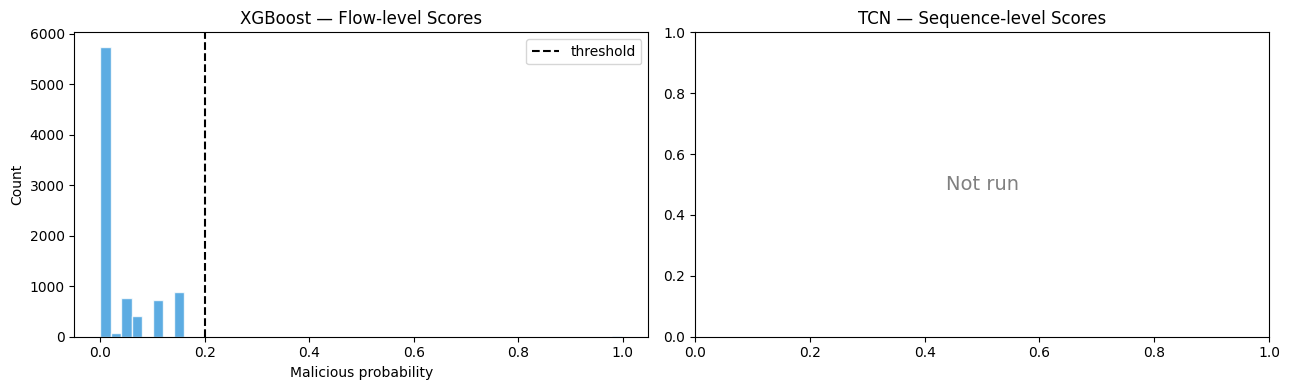

Saved → ./outputs/score_distributions.png


In [374]:
# ── Probability score distributions ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (results, col, title, color) in zip(
    axes,
    [
        (xgb_results, "xgb_prob", "XGBoost — Flow-level Scores", "#3498db"),
        (tcn_results, "tcn_prob", "TCN — Sequence-level Scores",  "#e74c3c"),
    ],
):
    if results is not None and col in results.columns:
        ax.hist(results[col], bins=50, color=color, alpha=0.8, edgecolor="white")
        ax.axvline(XGB_THRESHOLD if "xgb" in col else TCN_THRESHOLD,
                   color="black", linestyle="--", linewidth=1.5,
                   label=f"threshold")
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Malicious probability")
        ax.set_ylabel("Count")
        ax.legend()
    else:
        ax.text(0.5, 0.5, "Not run", ha="center", va="center",
                transform=ax.transAxes, fontsize=14, color="gray")
        ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "score_distributions.png"), dpi=150)
plt.show()
print(f"Saved → {OUTPUT_DIR}/score_distributions.png")


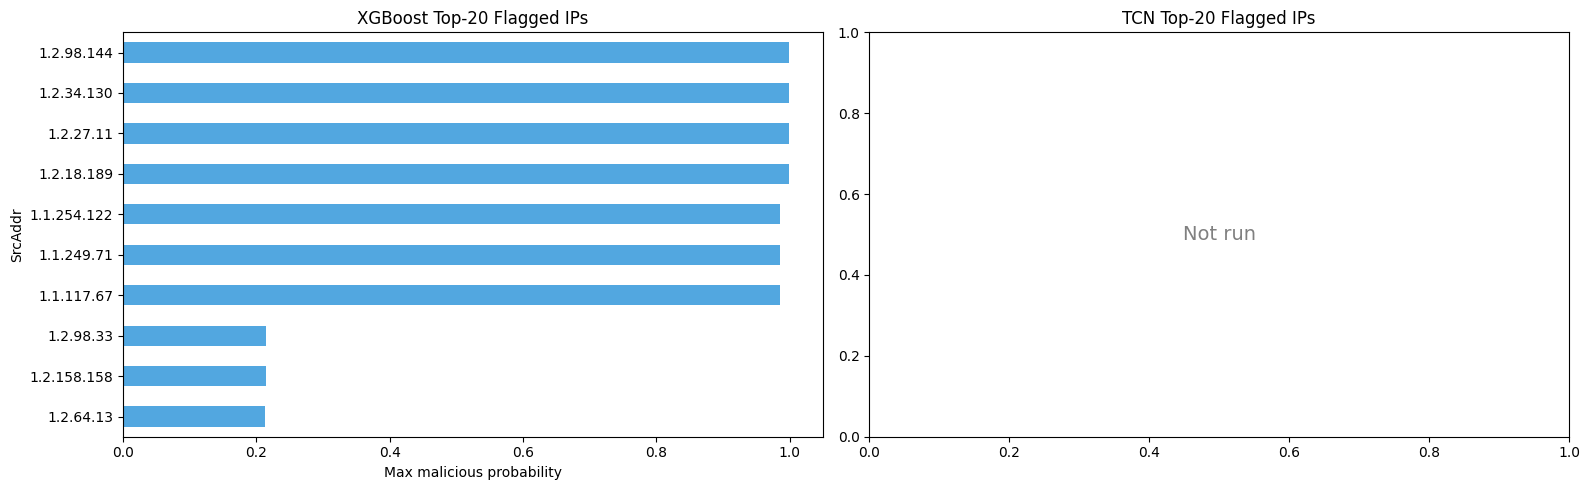

Saved → ./outputs/top_flagged_ips.png


In [375]:
# ── Top-20 flagged source IPs ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (results, prob_col, alert_col, title, color) in zip(
    axes,
    [
        (xgb_results, "xgb_prob", "xgb_alert", "XGBoost Top-20 Flagged IPs", "#3498db"),
        (tcn_results, "tcn_prob", "tcn_alert",  "TCN Top-20 Flagged IPs",     "#e74c3c"),
    ],
):
    if results is not None and prob_col in results.columns:
        flagged = results[results[alert_col] == 1]
        if len(flagged) == 0:
            ax.text(0.5, 0.5, "No alerts", ha="center", va="center",
                    transform=ax.transAxes, fontsize=14, color="gray")
        else:
            top = (flagged.groupby("SrcAddr")[prob_col]
                   .max().sort_values(ascending=False).head(20))
            top.sort_values().plot(kind="barh", ax=ax, color=color, alpha=0.85)
            ax.set_xlabel("Max malicious probability")
            ax.set_title(title, fontsize=12)
    else:
        ax.text(0.5, 0.5, "Not run", ha="center", va="center",
                transform=ax.transAxes, fontsize=14, color="gray")
        ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top_flagged_ips.png"), dpi=150)
plt.show()
print(f"Saved → {OUTPUT_DIR}/top_flagged_ips.png")


## Cell 9 — Export Results to CSV

In [376]:
if xgb_results is not None:
    out_path = os.path.join(OUTPUT_DIR, "xgb_results.csv")
    xgb_results.to_csv(out_path, index=False)
    print(f"XGBoost results  → {out_path}  ({len(xgb_results):,} rows)")

if tcn_results is not None:
    out_path = os.path.join(OUTPUT_DIR, "tcn_results.csv")
    tcn_results.to_csv(out_path, index=False)
    print(f"TCN results      → {out_path}  ({len(tcn_results):,} rows)")

# ── Per-IP alert summary ──────────────────────────────────────────────
summary_rows = []
all_ips = set()
if xgb_results is not None:
    all_ips |= set(xgb_results["SrcAddr"].unique())
if tcn_results is not None:
    all_ips |= set(tcn_results["SrcAddr"].unique())

for ip in sorted(all_ips):
    row = {"SrcAddr": ip}
    if xgb_results is not None:
        sub = xgb_results[xgb_results["SrcAddr"] == ip]
        row["xgb_max_prob"]    = float(sub["xgb_prob"].max()) if len(sub) else float("nan")
        row["xgb_alert_flows"] = int(sub["xgb_alert"].sum()) if len(sub) else 0
    if tcn_results is not None:
        sub = tcn_results[tcn_results["SrcAddr"] == ip]
        row["tcn_max_prob"]    = float(sub["tcn_prob"].max())  if len(sub) else float("nan")
        row["tcn_alert_seqs"]  = int(sub["tcn_alert"].sum())  if len(sub) else 0
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
out_path = os.path.join(OUTPUT_DIR, "per_ip_alert_summary.csv")
df_summary.to_csv(out_path, index=False)
print(f"Per-IP summary   → {out_path}  ({len(df_summary):,} unique IPs)")
df_summary.sort_values(
    [c for c in ["xgb_max_prob", "tcn_max_prob"] if c in df_summary.columns],
    ascending=False
).head(10)


XGBoost results  → ./outputs/xgb_results.csv  (8,629 rows)
Per-IP summary   → ./outputs/per_ip_alert_summary.csv  (8,315 unique IPs)


,SrcAddr,xgb_max_prob,xgb_alert_flows
8267,1.2.98.144,0.999500,1
6871,1.2.34.130,0.999455,1
5000,1.2.18.189,0.999455,1
6690,1.2.27.11,0.999455,1
2076,1.1.249.71,0.985889,1
2146,1.1.254.122,0.985889,1
260,1.1.117.67,0.985889,1
8280,1.2.98.33,0.214060,1
4449,1.2.158.158,0.214060,1
7517,1.2.64.13,0.213296,1
